# XÁC ĐỊNH LUẬT KẾT HỢP TỪ TẬP PHỔ BIẾN

## 1. Mục tiêu

Mục tiêu của bài này là sử dụng giải thuật Apriori để xác định các tập phổ biến trong dữ liệu giao dịch Online Retail, từ đó trích xuất các luật kết hợp giữa các sản phẩm dựa trên các chỉ số support, confidence và lift, nhằm phát hiện mối quan hệ mua chung có ý nghĩa và hỗ trợ phân tích hành vi khách hàng.

## 2. Cài đặt thư viện và nạp dữ liệu

In [1]:
!pip install apyori

import pandas as pd
import matplotlib.pyplot as plt
from apyori import apriori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=3022530a1e69ec7c7c1cf479b61fcf41958949922d8667778a950e3f11ef7bb7
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [2]:
# Đọc dữ liệu Online Retail
online = pd.read_excel("Online Retail.xlsx", sheet_name="Online Retail")

print("5 dòng đầu tiên:")
print(online.head())

print("Thông tin dữ liệu:")
print(online.info())

5 dòng đầu tiên:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype   

**Nhận xét dữ liệu ban đầu:**

Dữ liệu gồm hơn 540.000 giao dịch với 8 thuộc tính mô tả chi tiết hoạt động mua bán tại cửa hàng trực tuyến trong năm 2010–2011. Một số cột có giá trị thiếu, đặc biệt là Description và CustomerID. Tuy nhiên, bài toán Apriori chỉ yêu cầu thông tin sản phẩm và hóa đơn nên các giá trị thiếu ở CustomerID không ảnh hưởng. Dữ liệu vẫn cần được làm sạch vì có các hóa đơn hủy (InvoiceNo chứa ký tự ‘C’) và các giao dịch có Quantity ≤ 0. Việc xử lý các vấn đề này giúp đảm bảo độ chính xác khi trích xuất tập phổ biến và luật kết hợp.

## 3. Tiền xử lý dữ liệu


*Bộ dữ liệu chứa nhiều hóa đơn bị hủy (InvoiceNo bắt đầu bằng 'C'), các giao dịch Quantity ≤ 0, hoặc các dòng có Description bị thiếu. Ta cần làm sạch trước khi đưa vào thuật toán Apriori.*

In [21]:
# Xác định hóa đơn bị hủy
online["IsCPresent"] = online["InvoiceNo"].astype(str).apply(lambda x: 1 if x.startswith('C') else 0)

# Lọc dữ liệu hợp lệ
online1 = (
    online
    .loc[online["Quantity"] > 0]
    .loc[online["IsCPresent"] != 1]
    .loc[:, ["InvoiceNo", "Description"]]
    .dropna()
)

print("Số dòng sau làm sạch:", len(online1))
online1.head()

Số dòng sau làm sạch: 530693


,InvoiceNo,Description
0,536365,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,WHITE METAL LANTERN
2,536365,CREAM CUPID HEARTS COAT HANGER
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,RED WOOLLY HOTTIE WHITE HEART.


**Nhận xét dữ liệu sau khi làm sạch:**

Sau khi loại bỏ hóa đơn hủy, các dòng thiếu mô tả sản phẩm và các giao dịch không hợp lệ (Quantity ≤ 0), tập dữ liệu còn hơn 530.000 dòng. Mỗi dòng bao gồm InvoiceNo và Description, phù hợp cho việc gom nhóm theo hóa đơn. Các mô tả sản phẩm sau xử lý đều đầy đủ, thống nhất, đảm bảo chất lượng cho việc xây dựng danh sách giao dịch đưa vào thuật toán Apriori.

## 4. Tạo danh sách giao dịch

*Giải thuật Apriori (trong thư viện apyori) yêu cầu dữ liệu ở dạng list các list, mỗi list là các sản phẩm trong một hóa đơn.*

In [22]:
# Lấy danh sách 5000 hóa đơn để chạy thuật toán nhanh hơn (giống hướng dẫn)
invoice_no_list = online1["InvoiceNo"].unique().tolist()
subset_invoice_no_list = invoice_no_list[:5000]

online_sub = online1[online1["InvoiceNo"].isin(subset_invoice_no_list)]

# Gom các sản phẩm theo InvoiceNo
transactions = [
    group["Description"].tolist()
    for invoice_no, group in online_sub.groupby("InvoiceNo")
]

print("Số giao dịch:", len(transactions))
print("3 giao dịch đầu tiên:")
transactions[:3]

Số giao dịch: 5000
3 giao dịch đầu tiên:


[['WHITE HANGING HEART T-LIGHT HOLDER',
  'WHITE METAL LANTERN',
  'CREAM CUPID HEARTS COAT HANGER',
  'KNITTED UNION FLAG HOT WATER BOTTLE',
  'RED WOOLLY HOTTIE WHITE HEART.',
  'SET 7 BABUSHKA NESTING BOXES',
  'GLASS STAR FROSTED T-LIGHT HOLDER'],
 ['HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT'],
 ['ASSORTED COLOUR BIRD ORNAMENT',
  "POPPY'S PLAYHOUSE BEDROOM ",
  "POPPY'S PLAYHOUSE KITCHEN",
  'FELTCRAFT PRINCESS CHARLOTTE DOLL',
  'IVORY KNITTED MUG COSY ',
  'BOX OF 6 ASSORTED COLOUR TEASPOONS',
  'BOX OF VINTAGE JIGSAW BLOCKS ',
  'BOX OF VINTAGE ALPHABET BLOCKS',
  'HOME BUILDING BLOCK WORD',
  'LOVE BUILDING BLOCK WORD',
  'RECIPE BOX WITH METAL HEART',
  'DOORMAT NEW ENGLAND']]

**Nhận xét danh sách giao dịch:**

Việc gom nhóm dữ liệu theo từng InvoiceNo tạo được 5000 giao dịch hợp lệ. Mỗi giao dịch là một danh sách sản phẩm được mua trong cùng một hóa đơn. Quan sát các giao dịch đầu tiên cho thấy khách hàng thường mua nhiều sản phẩm trong một lần đặt hàng. Điều này tạo điều kiện thuận lợi cho thuật toán Apriori phát hiện các tập mục thường xuất hiện cùng nhau.

## 5. Áp dụng Apriori tìm tập phổ biến

Ta đặt các tham số hợp lý:

min_support = 0.01 → xuất hiện ít nhất 1% giao dịch

min_confidence = 0.3 → độ tin cậy tối thiểu 30%

min_lift = 1.1 → mối quan hệ tốt hơn ngẫu nhiên

min_length = 2 → chỉ lấy tập phổ biến ≥ 2 sản phẩm

In [5]:
rules_generator = apriori(
    transactions,
    min_support = 0.01,
    min_confidence = 0.3,
    min_lift = 1.1,
    min_length = 2
)

results = list(rules_generator)
print("Số tập phổ biến tìm được:", len(results))

Số tập phổ biến tìm được: 1361


**Nhận xét kết quả Apriori – số lượng tập phổ biến:**

Với các tham số lựa chọn (support ≥ 0.01, confidence ≥ 0.3, lift ≥ 1.1), thuật toán Apriori đã tìm được 1361 tập phổ biến. Số lượng này cho thấy dữ liệu có nhiều nhóm sản phẩm được khách hàng mua kèm một cách đáng kể. Đây là cơ sở quan trọng để xây dựng các luật kết hợp nhằm phân tích hành vi mua hàng.

*Từ các tập phổ biến thu được ở bước Apriori, bước tiếp theo là xây dựng các luật kết hợp nhằm mô tả mối quan hệ mua kèm giữa các sản phẩm. Việc trích xuất luật kết hợp giúp chuyển các tập phổ biến thành các quy tắc có ý nghĩa thực tiễn hơn trong phân tích hành vi khách hàng.*

## 6. Trích xuất luật kết hợp từ tập phổ biến

Sau khi xác định được các tập phổ biến bằng giải thuật Apriori, bước tiếp theo là trích xuất các luật kết hợp có dạng:

*Antecedent → Consequent*

Mỗi luật kết hợp được đánh giá thông qua các chỉ số:

- Support: mức độ phổ biến của luật trong toàn bộ giao dịch

- Confidence: độ tin cậy của luật

- Lift: mức độ liên kết giữa các sản phẩm (lift > 1 cho thấy mối quan hệ có ý nghĩa)



In [6]:
# Trích xuất luật kết hợp từ kết quả Apriori
rules = []

for rel in results:
    support = rel.support
    for stat in rel.ordered_statistics:
        if len(stat.items_base) > 0 and len(stat.items_add) > 0:
            rules.append({
                "Antecedent": ", ".join(stat.items_base),
                "Consequent": ", ".join(stat.items_add),
                "Support": support,
                "Confidence": stat.confidence,
                "Lift": stat.lift
            })

rules_df = pd.DataFrame(rules)
print("Tổng số luật kết hợp:", rules_df.shape[0])
rules_df.head()

Tổng số luật kết hợp: 2932


,Antecedent,Consequent,Support,Confidence,Lift
0,SET 2 TEA TOWELS I LOVE LONDON,LUNCH BOX I LOVE LONDON,0.0126,0.370588,7.952537
1,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,0.0152,0.550725,24.807416
2,12 PENCILS SMALL TUBE SKULL,12 PENCILS SMALL TUBE RED RETROSPOT,0.0152,0.684685,24.807416
3,3 PIECE SPACEBOY COOKIE CUTTER SET,GINGERBREAD MAN COOKIE CUTTER,0.0102,0.392308,8.454907
4,3 STRIPEY MICE FELTCRAFT,FELTCRAFT 6 FLOWER FRIENDS,0.0106,0.438017,11.117171


**Nhận xét:**

- Trích xuất được 2932 luật kết hợp dạng A → B (mua A thì hay mua kèm B).

- Support ~ 1%–1.5%: các luật xuất hiện không quá nhiều nhưng hợp lý với dữ liệu bán lẻ.

- Confidence cho biết độ tin cậy (vd ~55% nghĩa là mua A thì ~55% mua thêm B).

- Lift đều > 1 (nhiều luật lift rất cao ~8–25) ⇒ mua kèm mạnh hơn ngẫu nhiên, thường là sản phẩm cùng bộ/chủ đề.

- Có thể lọc tiếp theo confidence hoặc lift để lấy các luật tốt nhất cho gợi ý mua kèm.

*Mặc dù đã trích xuất được một số lượng lớn luật kết hợp, không phải tất cả các luật đều có giá trị sử dụng trong thực tế. Do đó, cần áp dụng các tiêu chí lọc để tập trung vào những luật có ý nghĩa. Trong phần tiếp theo, bài toán tiến hành lọc luật theo độ tin cậy (confidence) nhằm ưu tiên các luật có khả năng dự đoán cao.*

## 7. Case 1 – Lọc luật theo Confidence ≥ 0.6

In [7]:
rules_case1 = rules_df[rules_df["Confidence"] >= 0.6] \
    .sort_values(["Confidence", "Lift"], ascending=False)

print("Số luật thỏa confidence ≥ 0.6:", rules_case1.shape[0])
rules_case1.head(6)

Số luật thỏa confidence ≥ 0.6: 1064


,Antecedent,Consequent,Support,Confidence,Lift
2930,"POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE B...",POPPY'S PLAYHOUSE BEDROOM,0.0110,1.0,34.013605
1291,"FLORAL FOLK STATIONERY SET, BEADED CRYSTAL HEA...",DOTCOM POSTAGE,0.0102,1.0,22.321429
1295,"GREEN REGENCY TEACUP AND SAUCER, BEADED CRYSTA...",DOTCOM POSTAGE,0.0104,1.0,22.321429
1300,"HEART DECORATION RUSTIC HANGING , BEADED CRYST...",DOTCOM POSTAGE,0.0112,1.0,22.321429
1308,"JAM MAKING SET PRINTED, BEADED CRYSTAL HEART P...",DOTCOM POSTAGE,0.0108,1.0,22.321429
1312,"LOVEBIRD HANGING DECORATION WHITE , BEADED CRY...",DOTCOM POSTAGE,0.0102,1.0,22.321429


**Nhận xét:**

- Lọc Confidence ≥ 0.6 thu được 1064 luật ⇒ nhiều quan hệ mua kèm có độ tin cậy cao.

- Top luật có Confidence = 1.0 ⇒ mua vế trái thì gần như chắc chắn có vế phải.

- Lift rất cao (≈ 22–34) ⇒ liên kết mạnh hơn ngẫu nhiên, thường là sản phẩm cùng bộ/đi kèm.

- Nhiều luật ra DOTCOM POSTAGE: có thể là dòng phí kèm hóa đơn ⇒ cân nhắc loại nếu chỉ phân tích sản phẩm.

*Trong khi confidence phản ánh độ tin cậy của luật theo một chiều cụ thể, chỉ số lift lại cho biết mức độ liên kết giữa các sản phẩm so với trường hợp ngẫu nhiên. Vì vậy, ngoài việc lọc theo confidence, bài toán tiếp tục xem xét các luật có lift rất cao để phát hiện những mối quan hệ mua kèm đặc biệt mạnh.*

## 8. Case 2 – Lọc luật theo Lift ≥ 50

In [8]:
rules_case2 = rules_df[rules_df["Lift"] >= 50] \
    .sort_values("Lift", ascending=False)

print("Số luật thỏa lift ≥ 50:", rules_case2.shape[0])
rules_case2.head(6)

Số luật thỏa lift ≥ 50: 170


,Antecedent,Consequent,Support,Confidence,Lift
2780,"CHRISTMAS TREE HEART DECORATION, DOTCOM POSTAGE","CHRISTMAS TREE DECORATION WITH BELL, CHRISTMAS...",0.0104,0.896552,74.712644
2777,"CHRISTMAS TREE STAR DECORATION, CHRISTMAS TREE...","CHRISTMAS TREE HEART DECORATION, DOTCOM POSTAGE",0.0104,0.866667,74.712644
2181,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER CHIVES,0.0102,0.809524,73.593074
2176,HERB MARKER CHIVES,"HERB MARKER MINT, HERB MARKER THYME",0.0102,0.927273,73.593074
2776,"CHRISTMAS TREE HEART DECORATION, CHRISTMAS TRE...","DOTCOM POSTAGE, CHRISTMAS TREE STAR DECORATION",0.0104,0.866667,72.222222
2781,"DOTCOM POSTAGE, CHRISTMAS TREE STAR DECORATION","CHRISTMAS TREE HEART DECORATION, CHRISTMAS TRE...",0.0104,0.866667,72.222222


**Nhận xét:**

- Lọc Lift ≥ 50 còn 170 luật ⇒ nhóm luật có liên kết mua kèm cực mạnh.

- Top luật có lift ~72–75, confidence ~0.81–0.93 ⇒ mua vế trái thì rất hay có vế phải.

- Support ~ 1%: combo không quá phổ biến nhưng “đi kèm rất chắc” khi xuất hiện.

- Nhiều luật chứa DOTCOM POSTAGE (dòng phí) ⇒ nếu chỉ phân tích sản phẩm thì nên loại item này để luật “thực” hơn.

*Sau khi phân tích các luật kết hợp theo từng tiêu chí cụ thể (confidence và lift), việc trực quan hóa các chỉ số giúp quan sát tổng quan mối quan hệ giữa các luật. Phần tiếp theo trình bày các biểu đồ nhằm minh họa mối quan hệ giữa support, confidence và lift của các luật kết hợp.*

### 8.1. Một số luật kết hợp mạnh tiêu biểu

In [19]:
# Bảng top 5 luật mạnh nhất

rules_df.sort_values(
    ["Lift", "Confidence"], ascending=False
).head(5)

,Antecedent,Consequent,Support,Confidence,Lift
2780,"CHRISTMAS TREE HEART DECORATION, DOTCOM POSTAGE","CHRISTMAS TREE DECORATION WITH BELL, CHRISTMAS...",0.0104,0.896552,74.712644
2777,"CHRISTMAS TREE STAR DECORATION, CHRISTMAS TREE...","CHRISTMAS TREE HEART DECORATION, DOTCOM POSTAGE",0.0104,0.866667,74.712644
2176,HERB MARKER CHIVES,"HERB MARKER MINT, HERB MARKER THYME",0.0102,0.927273,73.593074
2181,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER CHIVES,0.0102,0.809524,73.593074
2776,"CHRISTMAS TREE HEART DECORATION, CHRISTMAS TRE...","DOTCOM POSTAGE, CHRISTMAS TREE STAR DECORATION",0.0104,0.866667,72.222222


Bảng trên minh họa một số luật kết hợp có mức liên kết mạnh nhất trong dữ liệu.

## 9. Biểu đồ mối quan hệ giữa Support và Confidence

### 9.1. Biểu đồ phân tán (Scatter plot)

*Biểu đồ phân tán được sử dụng để quan sát mối quan hệ trực tiếp giữa Support và Confidence của các luật kết hợp.*

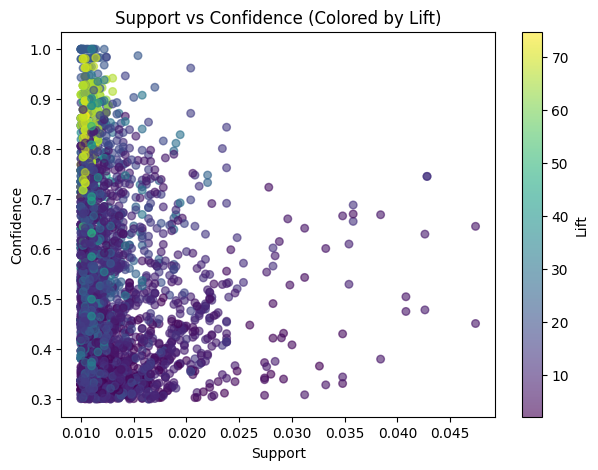

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(
    rules_df["Support"],
    rules_df["Confidence"],
    c=rules_df["Lift"],
    cmap="viridis",
    alpha=0.6,
    s=30
)
plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Colored by Lift)")
plt.show()

**Nhận xét biểu đồ phân tán:**

- Hầu hết luật có support rất thấp (~0.01–0.02) nên điểm tập trung dày bên trái.

- Confidence trải rộng (0.3–1.0) và không có xu hướng tuyến tính rõ ràng với support.

- Lift cao (màu sáng) thường nằm ở vùng support thấp ⇒ quan hệ mua kèm mạnh nhưng không quá phổ biến.

- Vì vậy nên chọn luật dựa trên confidence + lift, đồng thời cân nhắc support để luật ổn định hơn.

### 9.2. Biểu đồ mật độ Hexbin

*Để khắc phục hiện tượng các điểm bị chồng lên nhau, ta sử dụng hexbin plot, giúp thể hiện mật độ luật theo từng vùng Support–Confidence.*

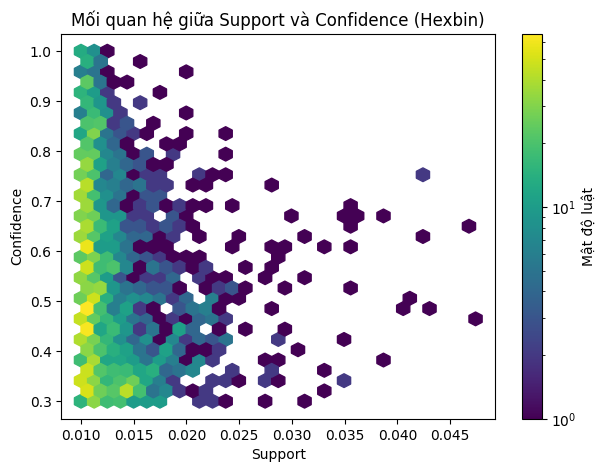

In [20]:
plt.figure(figsize=(7, 5))
plt.hexbin(rules_df["Support"], rules_df["Confidence"],
           gridsize=30, bins="log", cmap="viridis")

plt.colorbar(label="Mật độ luật")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Mối quan hệ giữa Support và Confidence (Hexbin)")
plt.show()

**Nhận xét:**

Biểu đồ hexbin cho thấy mật độ luật tập trung chủ yếu ở vùng support thấp. Tuy nhiên, do dữ liệu phân bố lệch mạnh, biểu đồ này không trực quan bằng scatter plot trong việc phân tích mối quan hệ giữa Support và Confidence.


*Trong khi biểu đồ ở Phần 9 cho thấy mối quan hệ giữa support và confidence, việc xem xét riêng phân phối confidence sẽ giúp đánh giá tổng quan mức độ tin cậy của các luật kết hợp. Do đó, phần tiếp theo trình bày biểu đồ phân phối confidence của toàn bộ các luật.*

## 10. Phân phối Confidence của các luật kết hợp

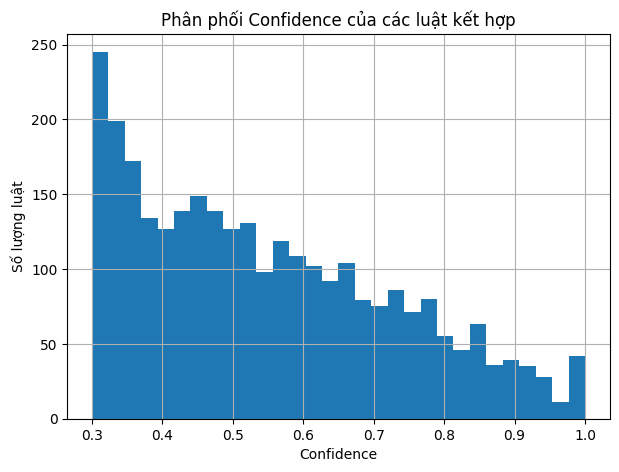

In [10]:
rules_df["Confidence"].hist(bins=30, figsize=(7, 5))
plt.xlabel("Confidence")
plt.ylabel("Số lượng luật")
plt.title("Phân phối Confidence của các luật kết hợp")
plt.show()

**Nhận xét:**

- Phần lớn luật có confidence trong khoảng 0.3–0.5, chiếm số lượng lớn nhất.

- Số luật giảm dần khi confidence tăng, đặc biệt từ 0.6 trở lên.

- Các luật có confidence cao (≥ 0.8) ít hơn nhưng đáng tin cậy hơn.

- Biểu đồ cho thấy cần lọc luật theo confidence để chọn các luật có ý nghĩa.

*Kết quả này củng cố tính hợp lý của việc lọc luật theo confidence trong Case 1 nhằm tập trung vào các luật có độ tin cậy cao và giá trị ứng dụng thực tiễn.*

## 11. Kết luận và thảo luận

- Áp dụng Apriori thành công để tìm tập phổ biến và luật kết hợp từ dữ liệu Online Retail.

- Thu được 1361 tập phổ biến và 2932 luật kết hợp.

- Lọc theo confidence và lift giúp chọn ra các luật mua kèm có ý nghĩa.

- Nhiều luật có support thấp nhưng confidence/lift cao, đặc trưng của dữ liệu bán lẻ.

- Kết quả có thể dùng cho gợi ý sản phẩm và phân tích hành vi mua hàng.

**Nhận xét tổng quát:**

Kết quả cho thấy dữ liệu Online Retail tồn tại nhiều luật kết hợp có support thấp nhưng confidence và lift cao. Điều này phản ánh đặc trưng phổ biến của dữ liệu bán lẻ với số lượng sản phẩm lớn và hành vi mua sắm đa dạng. Các luật có lift cao thường liên quan đến các sản phẩm cùng bộ hoặc cùng chủ đề, trong khi các luật có support cao hơn nhưng lift thấp thể hiện các mối quan hệ phổ biến nhưng không quá đặc biệt. Do đó, việc kết hợp nhiều chỉ số đánh giá là cần thiết để lựa chọn các luật có ý nghĩa thực tiễn.

## 12. Ứng dụng thực tiễn của luật kết hợp

Các luật kết hợp thu được từ dữ liệu Online Retail có thể được ứng dụng trong hệ thống gợi ý sản phẩm, giúp đề xuất các sản phẩm mua kèm phù hợp cho khách hàng. Ngoài ra, các luật này còn hỗ trợ thiết kế các gói sản phẩm bán kèm (bundle), tối ưu bố trí sản phẩm trên website và phân tích hành vi mua sắm nhằm nâng cao hiệu quả kinh doanh.


## 13. Hạn chế của bài toán và hướng phát triển

Bài toán chỉ sử dụng một phần dữ liệu (5000 hóa đơn) nhằm giảm thời gian tính toán, do đó kết quả có thể chưa phản ánh đầy đủ toàn bộ tập dữ liệu. Ngoài ra, sự xuất hiện của một số mục đặc biệt như DOTCOM POSTAGE có thể ảnh hưởng đến kết quả luật kết hợp. Trong tương lai, có thể mở rộng bài toán bằng cách xử lý toàn bộ dữ liệu, loại bỏ các mục không phải sản phẩm thực, hoặc thử nghiệm các thuật toán khác như FP-Growth để so sánh hiệu quả.


# Kết thúc